In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy as sp
import statsmodels.api as sm
import seaborn as sns
import bambi as bmb
import arviz as az
from sklearn.preprocessing import StandardScaler

def remove_nulls_simple(data_subset, variables):
        # Drop rows where any of the specified variable columns have nulls
        data_subset_cleaned = data_subset.dropna(subset=variables, ignore_index=True)
        # Subsets the cleaned dataframe back into only chosen variables
        vars_cleaned = data_subset_cleaned[variables]
        return vars_cleaned

def list_to_str(list_name):
    string = " + ".join(list_name)
    return string

pa_gs = pd.read_csv('data/pa_data.csv')
temps = pd.read_csv("data/pa_temps_supplement.csv")
pa_gs = pa_gs.merge(temps, on=["station_id", "year"], how="left")

pa_gs = pa_gs[pa_gs['year'] >= 1960]
pa_gs = pa_gs.drop(['station_id', 'last_spring_frost_date', 'first_fall_frost_date', 'station_name','state'], axis=1)

def bayesian_model_unstandardized(data, target_var_name, cov_list):

    cov_str = list_to_str(cov_list)
    cov_list_target_var = list(cov_list) + [target_var_name] + ['year']
    data = remove_nulls_simple(data, cov_list_target_var)
    
    formula = bmb.Formula(f"{target_var_name} ~ {cov_str} + year",
                      f"sigma ~ {cov_str} + year")
    model = bmb.Model(formula, data=data, dropna = True)
    output = model.fit(idata_kwargs={'log_likelihood':True})

    resid = data[target_var_name] - model.predict(output, inplace=False).posterior["mu"].mean(("chain", "draw")).values
    
    return model, output, resid

In [3]:
gsl_all_cov = ['dtr_annual','tmean_spring','tmean_fall','latitude','longitude','tmax_annual','oni_annual',
                'nao_annual','pna_annual','amo_annual','sst_north_atlantic','pwat_station','dewpoint_station',
                'soil_moisture_station','cloud_cover_station','evaporation_station', 'dtr_spring',
                'sst_gulf_mexico','pwat_southeast_us','dewpoint_2m_southeast_us','soil_moisture_southeast_us',
                'cloud_cover_southeast_us','evaporation_southeast_us']
dtr_all_cov = ['tmean_spring','tmean_fall','latitude','longitude','tmax_annual','oni_annual',
                'nao_annual','pna_annual','amo_annual','sst_north_atlantic','pwat_station','dewpoint_station',
                'soil_moisture_station','cloud_cover_station','evaporation_station',
                'sst_gulf_mexico','pwat_southeast_us','dewpoint_2m_southeast_us','soil_moisture_southeast_us',
                'cloud_cover_southeast_us','evaporation_southeast_us']

In [4]:
gsl_model, gsl_output, gsl_resid = bayesian_model_unstandardized(pa_gs, 'growing_season_length', gsl_all_cov)

                                                            Grad                                                  
  Progress               Draw        Divergen…   Step size   evals       Speed                Elapsed    Remaini…  
 ───────────────────────────────────────────────────────────────────────────────────────────────────────────────── 
  ━━━━━━━━━━━━━━━━━━━━   2000        0           0.151       31          131.78 draws/s       0:00:15    0:00:00   
  ━━━━━━━━━━━━━━━━━━━━   2000        0           0.157       31          75.87 draws/s        0:00:26    0:00:00   
  ━━━━━━━━━━━━━━━━━━━━   2000        0           0.106       31          132.00 draws/s       0:00:15    0:00:00   
  ━━━━━━━━━━━━━━━━━━━━   2000        0           0.127       31          117.98 draws/s       0:00:16    0:00:00

/home/reu/.venv/lib/python3.14/site-packages/pymc/sampling/mcmc.py:1163: FutureWarning: Passing `log_likelihood` via `idata_kwargs` is deprecated and will be removed in future versions. Call `pm.compute_log_likelihood(idata)` instead.
  return _sample_return(
Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 32 seconds.


In [5]:
dtr_model_all, dtr_output_all, dtr_resid_all = bayesian_model_unstandardized(pa_gs, 'dtr_annual', dtr_all_cov)

                                                            Grad                                                  
  Progress               Draw        Divergen…   Step size   evals       Speed                Elapsed    Remaini…  
 ───────────────────────────────────────────────────────────────────────────────────────────────────────────────── 
  ━━━━━━━━━━━━━━━━━━━━   2000        0           0.187       31          127.15 draws/s       0:00:15    0:00:00   
  ━━━━━━━━━━━━━━━━━━━━   2000        0           0.147       31          154.26 draws/s       0:00:12    0:00:00   
  ━━━━━━━━━━━━━━━━━━━━   2000        0           0.150       31          151.31 draws/s       0:00:13    0:00:00   
  ━━━━━━━━━━━━━━━━━━━━   2000        0           0.142       31          143.48 draws/s       0:00:13    0:00:00

/home/reu/.venv/lib/python3.14/site-packages/pymc/sampling/mcmc.py:1163: FutureWarning: Passing `log_likelihood` via `idata_kwargs` is deprecated and will be removed in future versions. Call `pm.compute_log_likelihood(idata)` instead.
  return _sample_return(
Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 21 seconds.


In [6]:
formula_dtr_yr = bmb.Formula(f"dtr_annual ~  year",
                      f"sigma ~ year")
model_dtr_yr = bmb.Model(formula_dtr_yr, data=pa_gs, dropna = True)
output_dtr_yr = model_dtr_yr.fit(idata_kwargs={'log_likelihood':True})

                                                            Grad                                                  
  Progress               Draw        Divergen…   Step size   evals       Speed                Elapsed    Remaini…  
 ───────────────────────────────────────────────────────────────────────────────────────────────────────────────── 
  ━━━━━━━━━━━━━━━━━━━━   2000        0           1.543       3           2305.64 draws/s      0:00:00    0:00:00   
  ━━━━━━━━━━━━━━━━━━━━   2000        0           0.893       3           2034.17 draws/s      0:00:00    0:00:00   
  ━━━━━━━━━━━━━━━━━━━━   2000        0           1.044       3           2400.51 draws/s      0:00:00    0:00:00   
  ━━━━━━━━━━━━━━━━━━━━   2000        0           0.927       3           2432.15 draws/s      0:00:00    0:00:00

/home/reu/.venv/lib/python3.14/site-packages/pymc/sampling/mcmc.py:1163: FutureWarning: Passing `log_likelihood` via `idata_kwargs` is deprecated and will be removed in future versions. Call `pm.compute_log_likelihood(idata)` instead.
  return _sample_return(
Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 2 seconds.


In [7]:
gsl_summary = pd.DataFrame()
gsl_summary = az.summary(gsl_output)
gsl_summary = gsl_summary[['mean']]
gsl_summary = gsl_summary.transpose()
gsl_summary.head(5)

,Intercept,dtr_annual,tmean_spring,tmean_fall,latitude,longitude,tmax_annual,oni_annual,nao_annual,pna_annual,...,sigma_cloud_cover_station,sigma_evaporation_station,sigma_dtr_spring,sigma_sst_gulf_mexico,sigma_pwat_southeast_us,sigma_dewpoint_2m_southeast_us,sigma_soil_moisture_southeast_us,sigma_cloud_cover_southeast_us,sigma_evaporation_southeast_us,sigma_year
mean,127,-9.5,1.25,5.771,-2.6,1.406,3.6,0.12,0.35,2.2,...,-0,-0.001,-0.0639,-0.103,-0.0227,0.063,-0.9,1.32,-0.138,-0.00477


In [76]:
print('95% Bayesian Significance Check, Mean of Response, GSL Model')
posteriors_dict = {}
gsl_all_cov_yr = gsl_all_cov + ['year']
for cov in gsl_all_cov_yr:
    posterior = gsl_output.posterior[f'{cov}']
    q05, q95 = float(posterior.quantile(.05)), float(posterior.quantile(.95))
    posteriors_dict[cov] = [q05, q95, q05 <= 0 <= q95]

gsl_posteriors_df = pd.DataFrame(posteriors_dict)
post_df_names = {0:'q05', 1:'q95', 2: "crosses 0"}
gsl_posteriors_df = gsl_posteriors_df.rename(index = post_df_names)

gsl_summary = pd.DataFrame()
gsl_summary = az.summary(gsl_output)
gsl_summary = gsl_summary[['mean']]
gsl_summary = gsl_summary.transpose()
gsl_summary = gsl_summary[gsl_all_cov_yr]
gsl_posteriors_df = pd.concat([gsl_posteriors_df, gsl_summary])

gsl_posteriors_df[['year', 'dtr_annual', 'tmean_spring']]

95% Bayesian Significance Check, Mean of Response, GSL Model


,year,dtr_annual,tmean_spring
q05,0.146905,-10.234907,0.817633
q95,0.273428,-8.766648,1.673178
crosses 0,False,False,False
mean,0.21,-9.5,1.25


In [86]:
print('95% Bayesian Significance Check, Variance of Response, GSL Model')
posteriors_dict = {}
gsl_all_cov_yr = gsl_all_cov + ['year']
for cov in gsl_all_cov_yr:
    posterior = gsl_output.posterior[f'sigma_{cov}']
    q05, q95 = float(posterior.quantile(.05)), float(posterior.quantile(.95))
    posteriors_dict[cov] = [q05, q95, q05 <= 0 <= q95]

gslv_posteriors_df = pd.DataFrame(posteriors_dict)
post_df_names = {0:'q05', 1:'q95', 2: "crosses 0"}
gslv_posteriors_df = gsl_posteriors_df.rename(index = post_df_names)

sigma_gsl_all_cov_yr = []
for cov in gsl_all_cov_yr:
    sigma_gsl_all_cov_yr += [f'sigma_{cov}']

gslv_posteriors_df.columns = sigma_gsl_all_cov_yr

gslv_summary = pd.DataFrame()
gslv_summary = az.summary(gsl_output)
gslv_summary = gslv_summary[['mean']]
gslv_summary = gslv_summary.transpose()
gslv_summary = gslv_summary[sigma_gsl_all_cov_yr]
gslv_posteriors_df = pd.concat([gslv_posteriors_df, gslv_summary])

gslv_posteriors_df[['sigma_year', 'sigma_dtr_annual', 'sigma_tmean_spring']]

95% Bayesian Significance Check, Variance of Response, GSL Model


,sigma_year,sigma_dtr_annual,sigma_tmean_spring
q05,0.146905,-10.234907,0.817633
q95,0.273428,-8.766648,1.673178
crosses 0,False,False,False
mean,0.21,-9.5,1.25
mean,-0.00477,0.1229,0.0296


In [27]:
print('95% Bayesian Significance Check, Mean of Response, DTR Model 1 (year)')
posteriors_dict = {}
dtr_all_cov_yr = ['year']
for cov in dtr_all_cov_yr:
    posterior = output_dtr_yr.posterior[f'{cov}']
    q05, q95 = float(posterior.quantile(.05)), float(posterior.quantile(.95))
    posteriors_dict[cov] = [q05, q95, q05 <= 0 <= q95]

dtr1_posteriors_df = pd.DataFrame(posteriors_dict)
post_df_names = {0:'q05', 1:'q95', 2: "crosses 0"}
dtr1_posteriors_df = dtr1_posteriors_df.rename(index = post_df_names)

dtr1_summary = pd.DataFrame()
dtr1_summary = az.summary(output_dtr_yr)
dtr1_summary = dtr1_summary[['mean']]
dtr1_summary = dtr1_summary.transpose()
dtr1_summary = dtr1_summary[dtr_all_cov_yr]
dtr1_posteriors_df = pd.concat([dtr1_posteriors_df, dtr1_summary])

dtr1_posteriors_df[['year']]

95% Bayesian Significance Check, Mean of Response, DTR Model 1 (year)


,year
q05,-0.014045
q95,-0.011073
crosses 0,False
mean,-0.01255


In [28]:
print('95% Bayesian Significance Check, Variance of Response, DTR Model 1 (year)')
posteriors_dict = {}
dtr_all_cov_yr = ['year']
for cov in dtr_all_cov_yr:
    posterior = output_dtr_yr.posterior[f'sigma_{cov}']
    q05, q95 = float(posterior.quantile(.05)), float(posterior.quantile(.95))
    posteriors_dict[cov] = [q05, q95, q05 <= 0 <= q95]

dtrv1_posteriors_df = pd.DataFrame(posteriors_dict)
post_df_names = {0:'q05', 1:'q95', 2: "crosses 0"}
dtrv1_posteriors_df = dtr1_posteriors_df.rename(index = post_df_names)

sigma_dtrv1_all_cov_yr = []
for cov in dtr_all_cov_yr:
    sigma_dtrv1_all_cov_yr += [f'sigma_{cov}']

dtrv1_posteriors_df = dtrv1_posteriors_df['year']
dtrv1_posteriors_df.columns = sigma_dtrv1_all_cov_yr

dtrv1_summary = pd.DataFrame()
dtrv1_summary = az.summary(output_dtr_yr)
dtrv1_summary = dtrv1_summary[['mean']]
dtrv1_summary = dtrv1_summary.transpose()
dtrv1_summary = dtrv1_summary[sigma_dtrv1_all_cov_yr]
dtrv1_posteriors_df = pd.concat([dtrv1_posteriors_df, dtrv1_summary])

dtrv1_posteriors_df[['year']]

95% Bayesian Significance Check, Variance of Response, DTR Model 1 (year)


,year
q05,-0.014045
q95,-0.011073
crosses 0,False
mean,-0.01255
mean,NaN


In [29]:
print('95% Bayesian Significance Check, Mean of Response, DTR Model 2')
posteriors_dict = {}
dtr_all_cov_yr = dtr_all_cov + ['year']
for cov in dtr_all_cov_yr:
    posterior = dtr_output_all.posterior[f'{cov}']
    q05, q95 = float(posterior.quantile(.05)), float(posterior.quantile(.95))
    posteriors_dict[cov] = [q05, q95, q05 <= 0 <= q95]

dtr2_posteriors_df = pd.DataFrame(posteriors_dict)
post_df_names = {0:'q05', 1:'q95', 2: "crosses 0"}
dtr2_posteriors_df = dtr2_posteriors_df.rename(index = post_df_names)

dtr2_summary = pd.DataFrame()
dtr2_summary = az.summary(dtr_output_all)
dtr2_summary = dtr2_summary[['mean']]
dtr2_summary = dtr2_summary.transpose()
dtr2_summary = dtr2_summary[dtr_all_cov_yr]
dtr2_posteriors_df = pd.concat([dtr2_posteriors_df, dtr2_summary])

dtr2_posteriors_df[['year', 'tmean_spring']]

95% Bayesian Significance Check, Mean of Response, DTR Model 2


,year,tmean_spring
q05,0.006913,-0.562861
q95,0.012376,-0.528337
crosses 0,False,False
mean,0.00967,-0.5457


In [40]:
print('95% Bayesian Significance Check, Variance of Response, DTR Model 2')
posteriors_dict = {}
dtr_all_cov_yr = dtr_all_cov + ['year']
for cov in dtr_all_cov_yr:
    posterior = dtr_output_all.posterior[f'sigma_{cov}']
    q05, q95 = float(posterior.quantile(.05)), float(posterior.quantile(.95))
    posteriors_dict[cov] = [q05, q95, q05 <= 0 <= q95]

dtrv2_posteriors_df = pd.DataFrame(posteriors_dict)
post_df_names = {0:'q05', 1:'q95', 2: "crosses 0"}
dtrv2_posteriors_df = dtrv2_posteriors_df.rename(index = post_df_names)

sigma_dtrv2_all_cov_yr = ['sigma_year', 'sigma_tmean_spring']
#for cov in dtr_all_cov_yr:
#    sigma_dtrv2_all_cov_yr += [f'sigma_{cov}']

dtrv2_posteriors_df = dtrv2_posteriors_df[['year', 'tmean_spring']]
dtrv2_posteriors_df.columns = sigma_dtrv2_all_cov_yr

dtrv2_summary = pd.DataFrame()
dtrv2_summary = az.summary(dtr_output_all)
dtrv2_summary = dtrv2_summary[['mean']]
dtrv2_summary = dtrv2_summary.transpose()
dtrv2_summary = dtrv2_summary[sigma_dtrv1_all_cov_yr]
dtrv2_posteriors_df = pd.concat([dtrv2_posteriors_df, dtrv2_summary])

dtrv2_posteriors_df[['sigma_year', 'sigma_tmean_spring']]

95% Bayesian Significance Check, Variance of Response, DTR Model 2


,sigma_year,sigma_tmean_spring
q05,0.006053,0.021295
q95,0.011682,0.048125
crosses 0,False,False
mean,0.00887,NaN


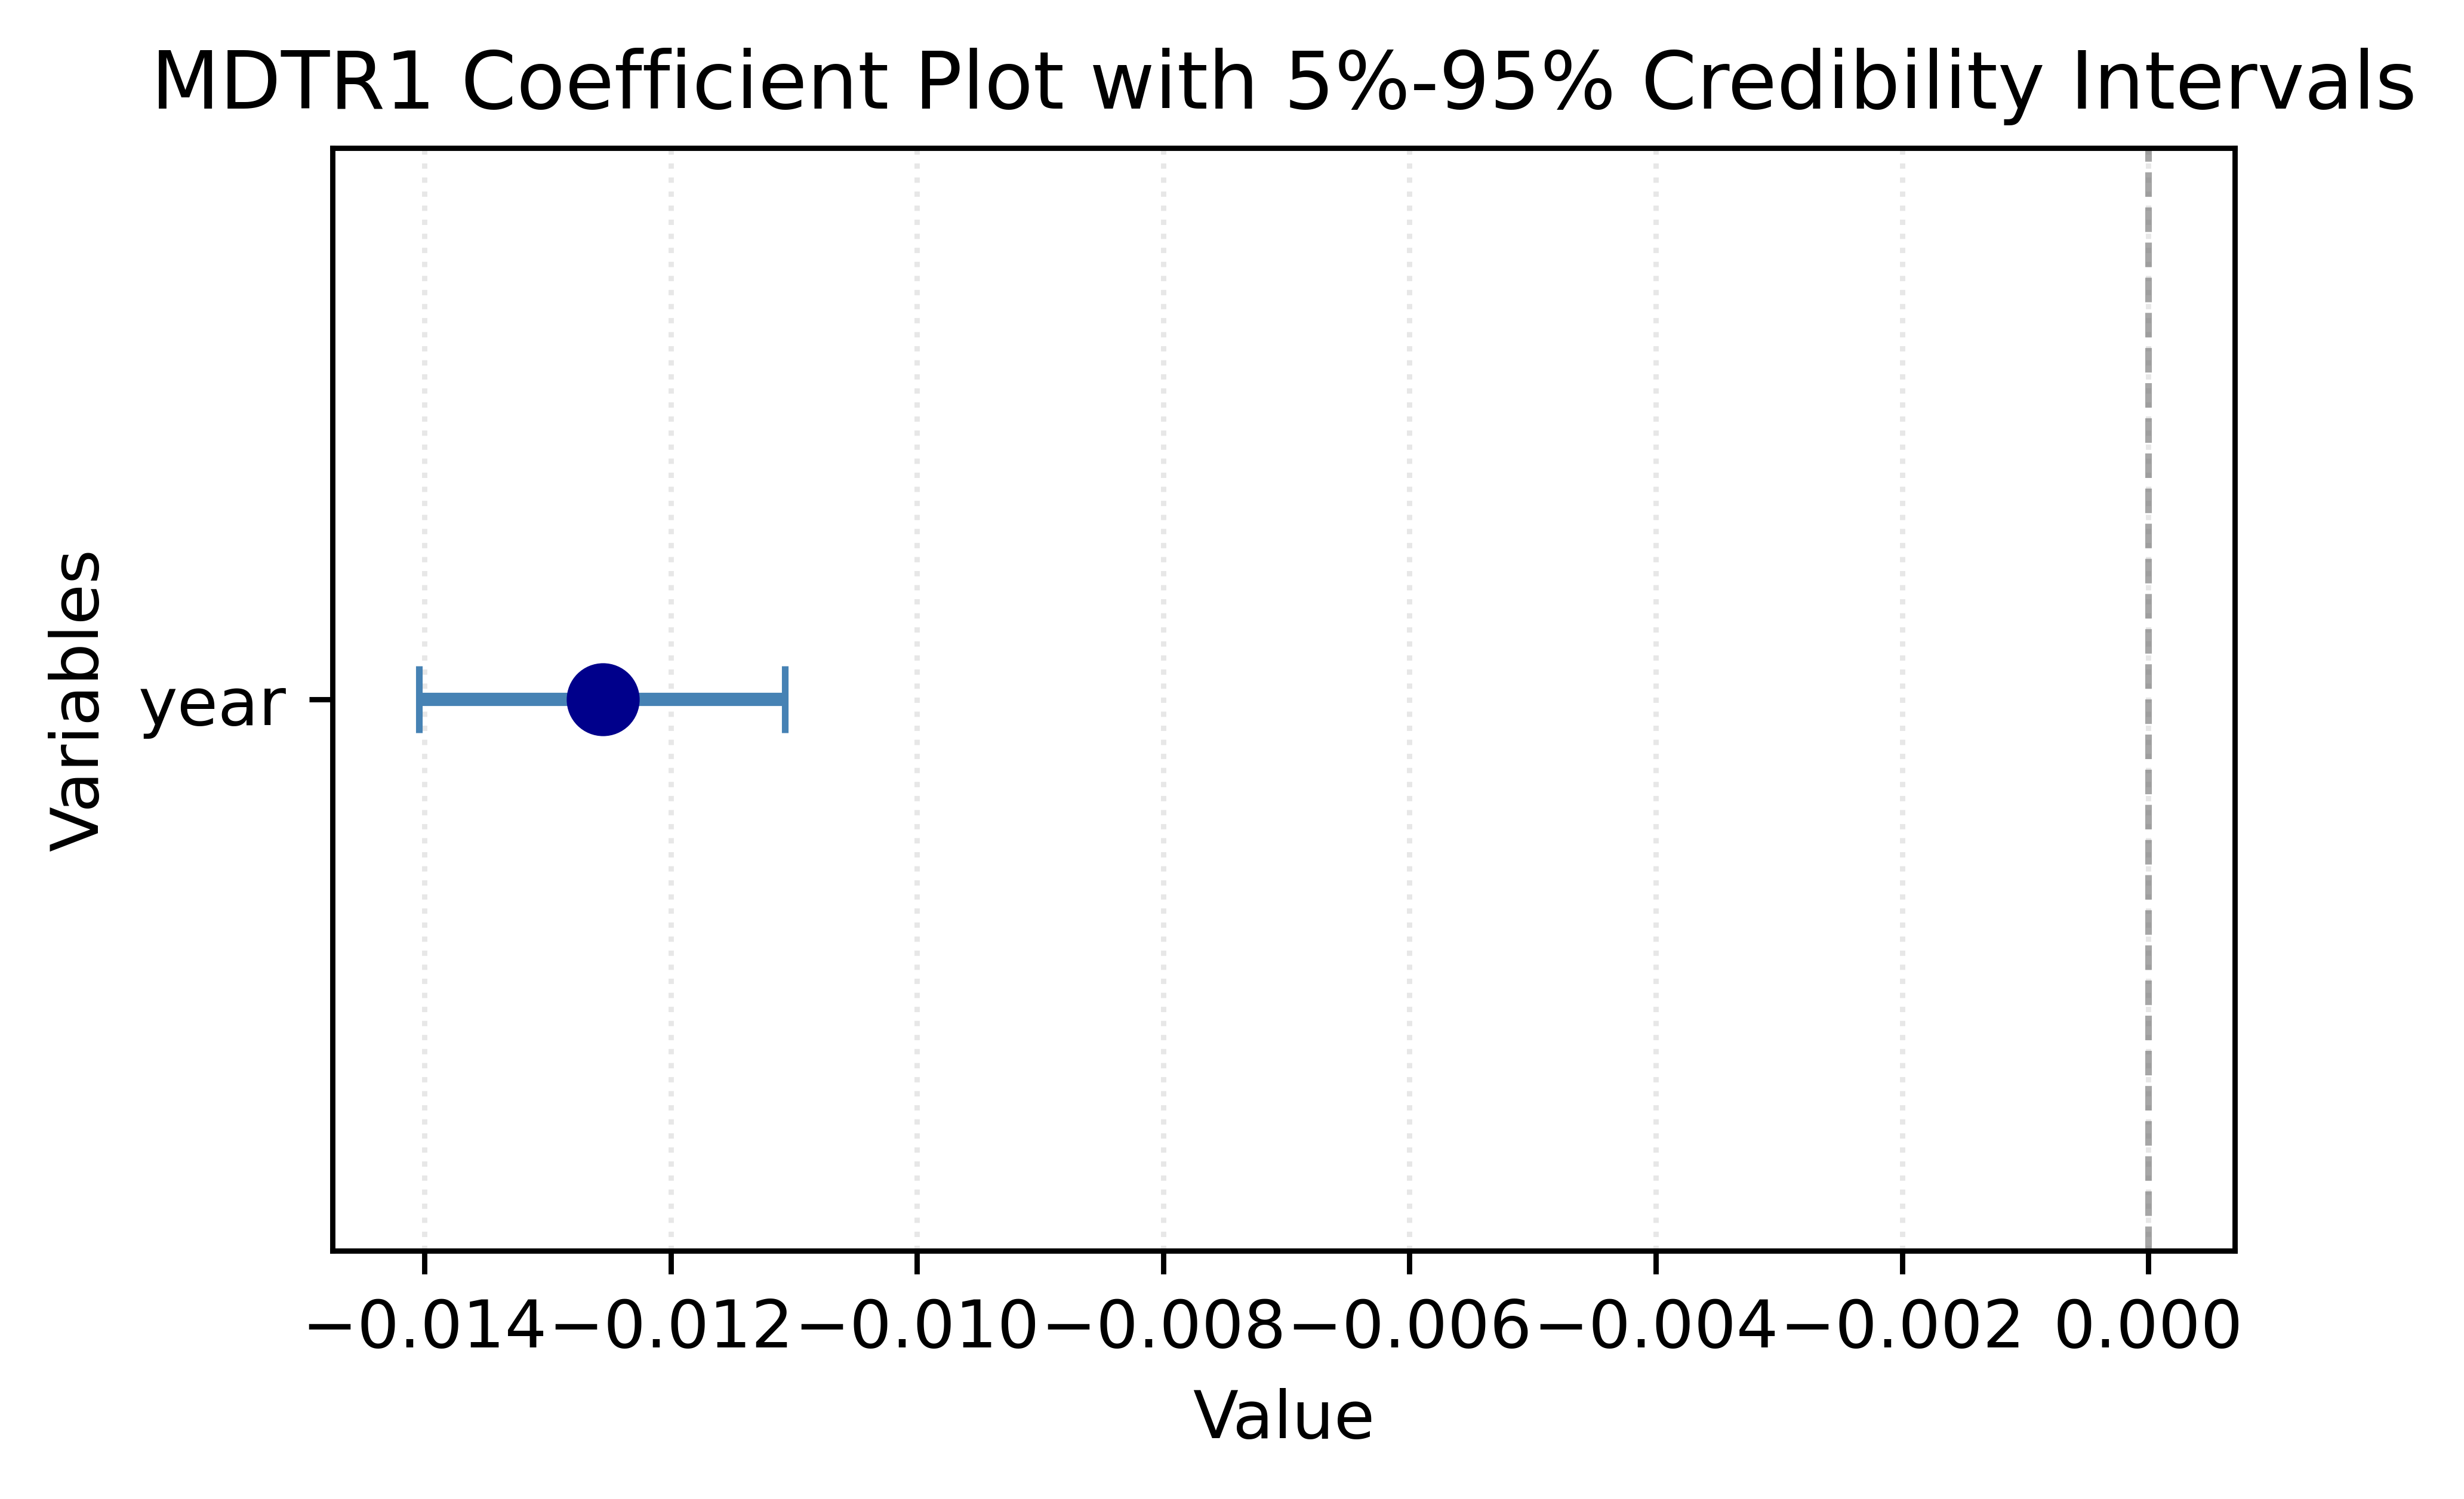

In [99]:
fig, ax = plt.subplots(figsize = (5.14,3))

dtr1_posteriors_plot = dtr1_posteriors_df[['year']]

quantile_5 = dtr1_posteriors_plot.loc['q05']
quantile_95 = dtr1_posteriors_plot.loc['q95']
mean_values = dtr1_posteriors_plot.loc['mean']

mean_values_float = mean_values.astype(float)
quantile_5_float = quantile_5.astype(float)
quantile_95_float = quantile_95.astype(float)

variables = mean_values.index.tolist()

lower_error = mean_values_float - quantile_5_float
upper_error = quantile_95_float - mean_values_float

y_positions = np.arange(len(variables))

ax.scatter(mean_values_float, y_positions, color='darkblue', s=100, zorder=3, label='Mean')

ax.errorbar(mean_values_float, y_positions, 
            xerr=[lower_error.values, upper_error.values],  # Convert Series to numpy arrays
            fmt='none', ecolor='steelblue', elinewidth=2, capsize=5, zorder=2)

ax.axvline(x=0, color='gray', linestyle='--', linewidth=1, alpha=0.7)

ax.set_yticks(y_positions)
ax.set_yticklabels(variables)

ax.set_xlabel('Value')
ax.set_ylabel('Variables')
ax.set_title('MDTR1 Coefficient Plot with 5%-95% Credibility Intervals')

ax.grid(axis='x', alpha=0.3, linestyle=':')

#plt.tight_layout()
plt.rcParams['figure.dpi'] = 800
plt.rcParams['savefig.dpi'] = 800
plt.show()

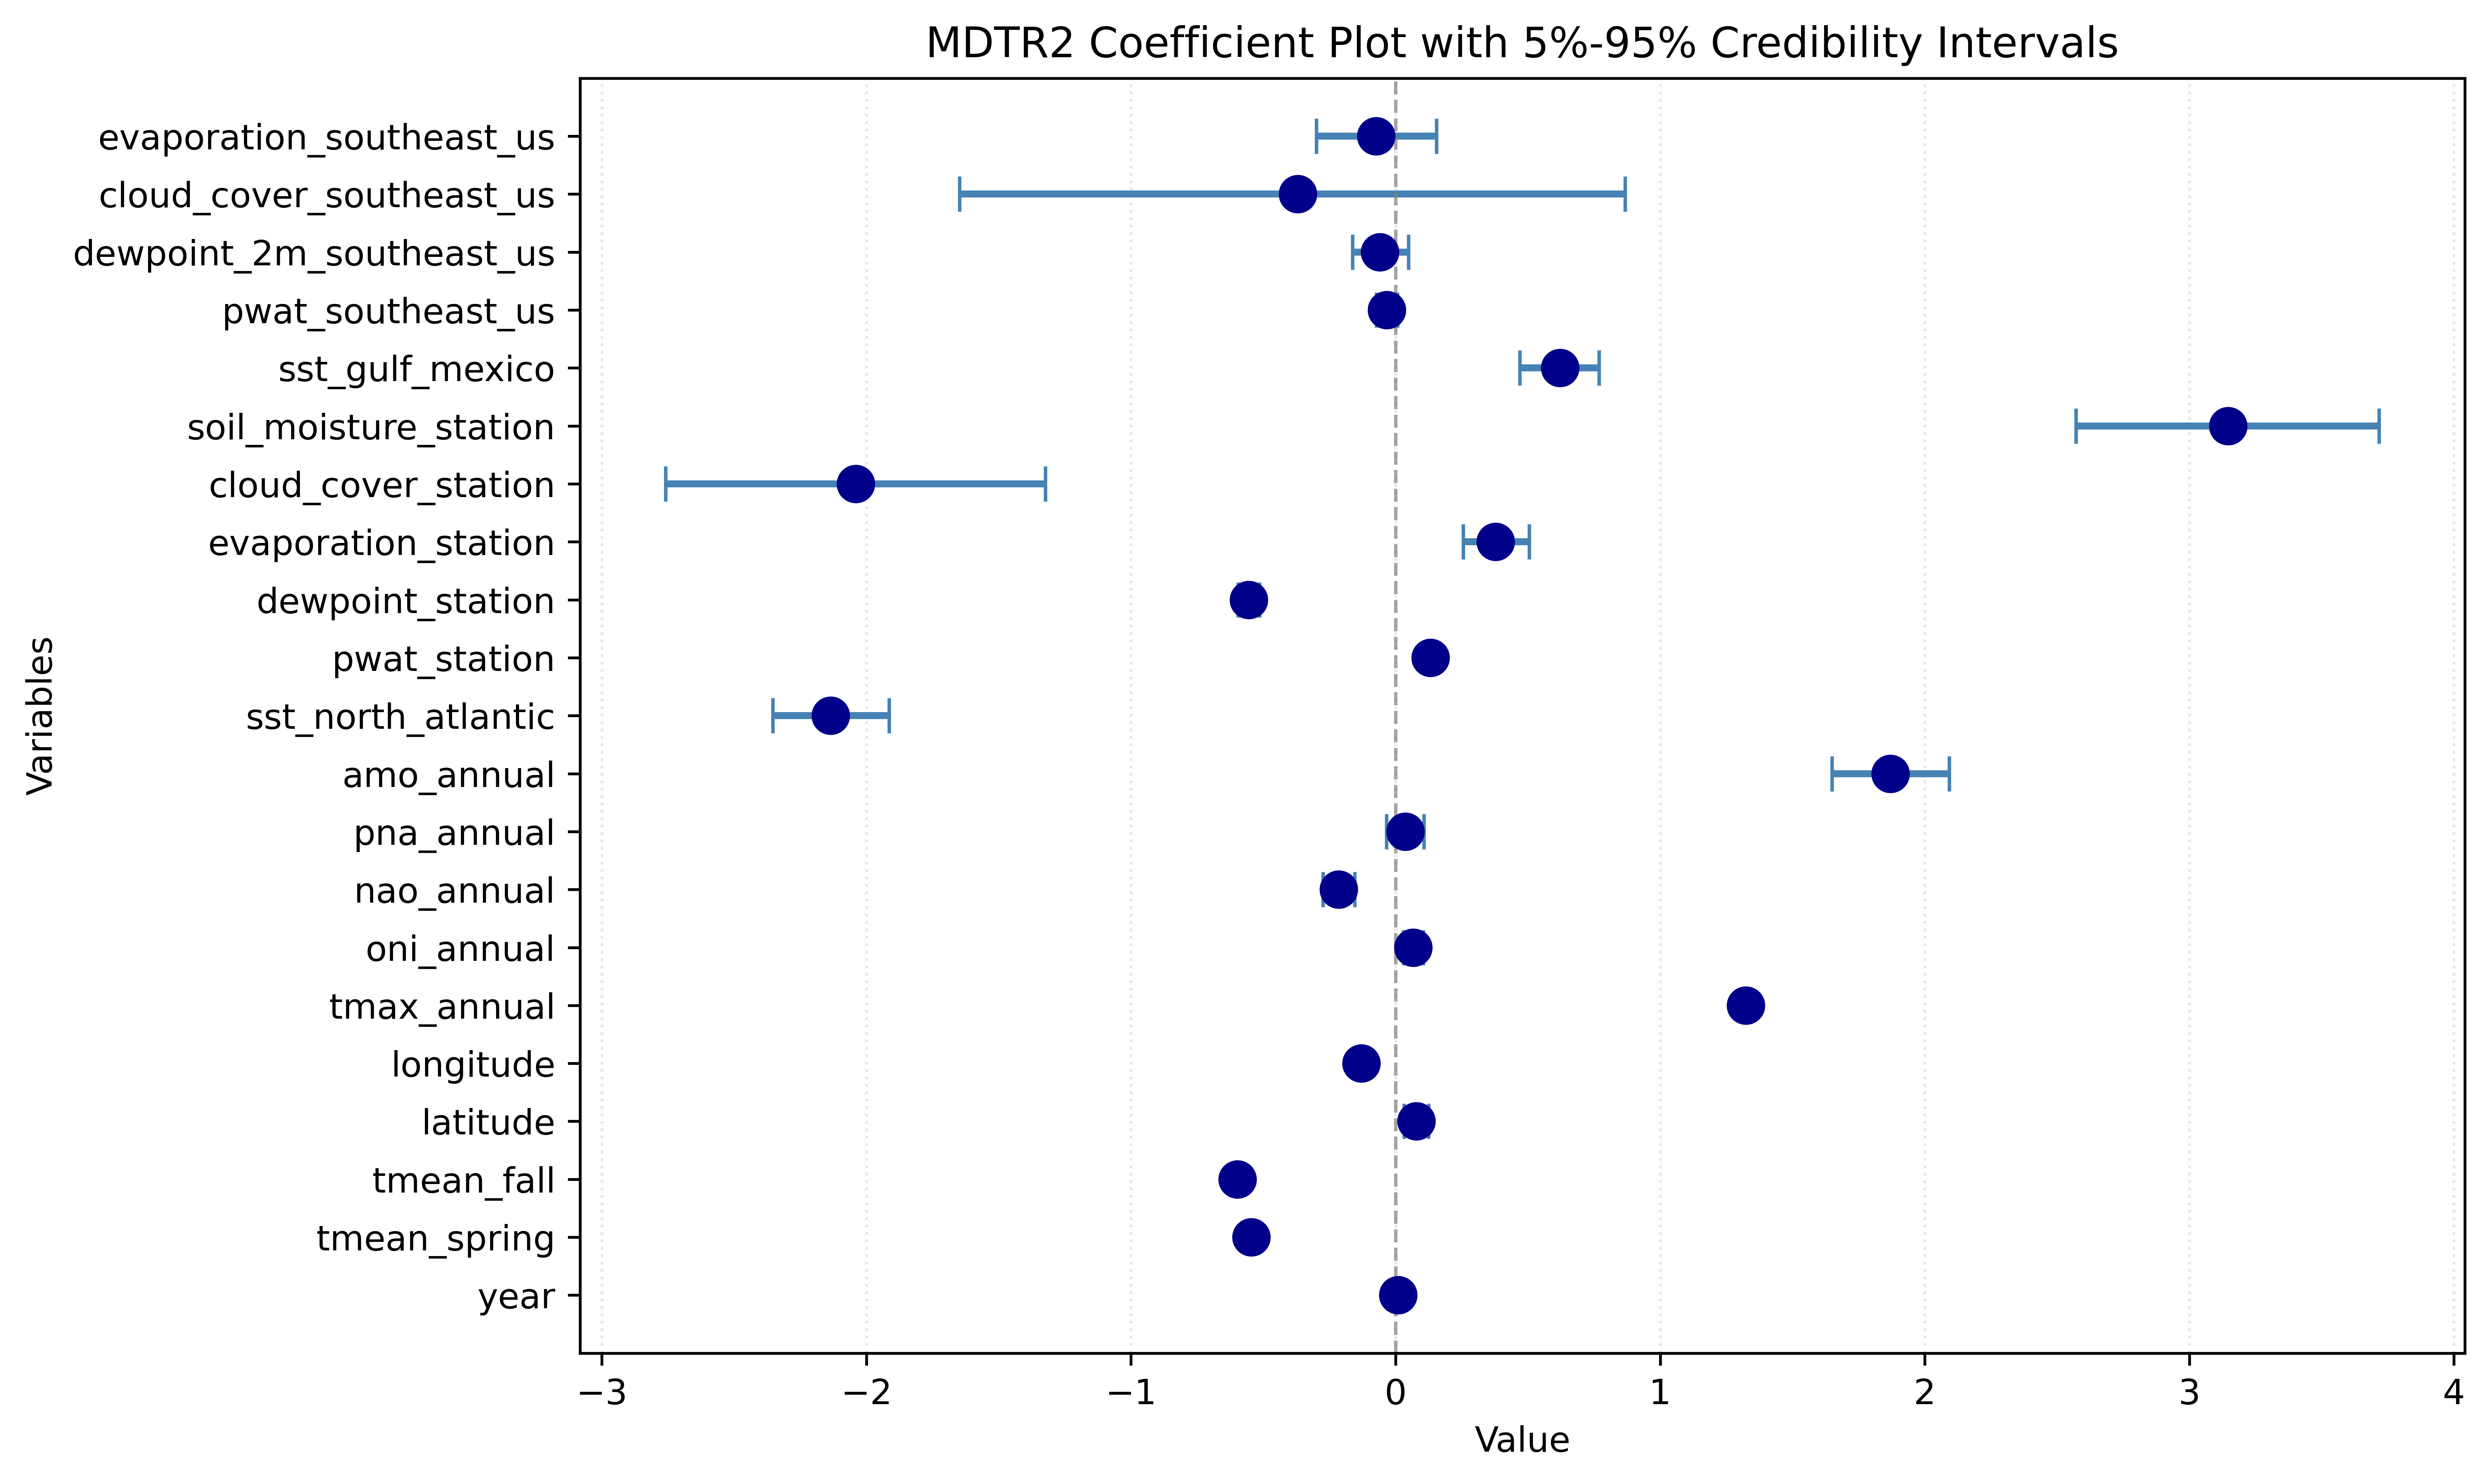

In [100]:
fig, ax = plt.subplots(figsize=(10, 6))

dtr2_posteriors_plot = dtr2_posteriors_df[['year','tmean_spring','tmean_fall','latitude','longitude','tmax_annual','oni_annual',
                'nao_annual','pna_annual','amo_annual','sst_north_atlantic','pwat_station','dewpoint_station',
                'evaporation_station', 'cloud_cover_station', 'soil_moisture_station',
                'sst_gulf_mexico','pwat_southeast_us','dewpoint_2m_southeast_us',
                'cloud_cover_southeast_us','evaporation_southeast_us']]

quantile_5 = dtr2_posteriors_plot.loc['q05']
quantile_95 = dtr2_posteriors_plot.loc['q95']
mean_values = dtr2_posteriors_plot.loc['mean']

mean_values_float = mean_values.astype(float)
quantile_5_float = quantile_5.astype(float)
quantile_95_float = quantile_95.astype(float)

variables = mean_values.index.tolist()

lower_error = mean_values_float - quantile_5_float
upper_error = quantile_95_float - mean_values_float

y_positions = np.arange(len(variables))

ax.scatter(mean_values_float, y_positions, color='darkblue', s=100, zorder=3, label='Mean')

ax.errorbar(mean_values_float, y_positions, 
            xerr=[lower_error.values, upper_error.values],  # Convert Series to numpy arrays
            fmt='none', ecolor='steelblue', elinewidth=2, capsize=5, zorder=2)

ax.axvline(x=0, color='gray', linestyle='--', linewidth=1, alpha=0.7)

ax.set_yticks(y_positions)
ax.set_yticklabels(variables)

ax.set_xlabel('Value')
ax.set_ylabel('Variables')
ax.set_title('MDTR2 Coefficient Plot with 5%-95% Credibility Intervals')

ax.grid(axis='x', alpha=0.3, linestyle=':')

plt.tight_layout()
plt.rcParams['figure.dpi'] = 800
plt.rcParams['savefig.dpi'] = 800
plt.show()

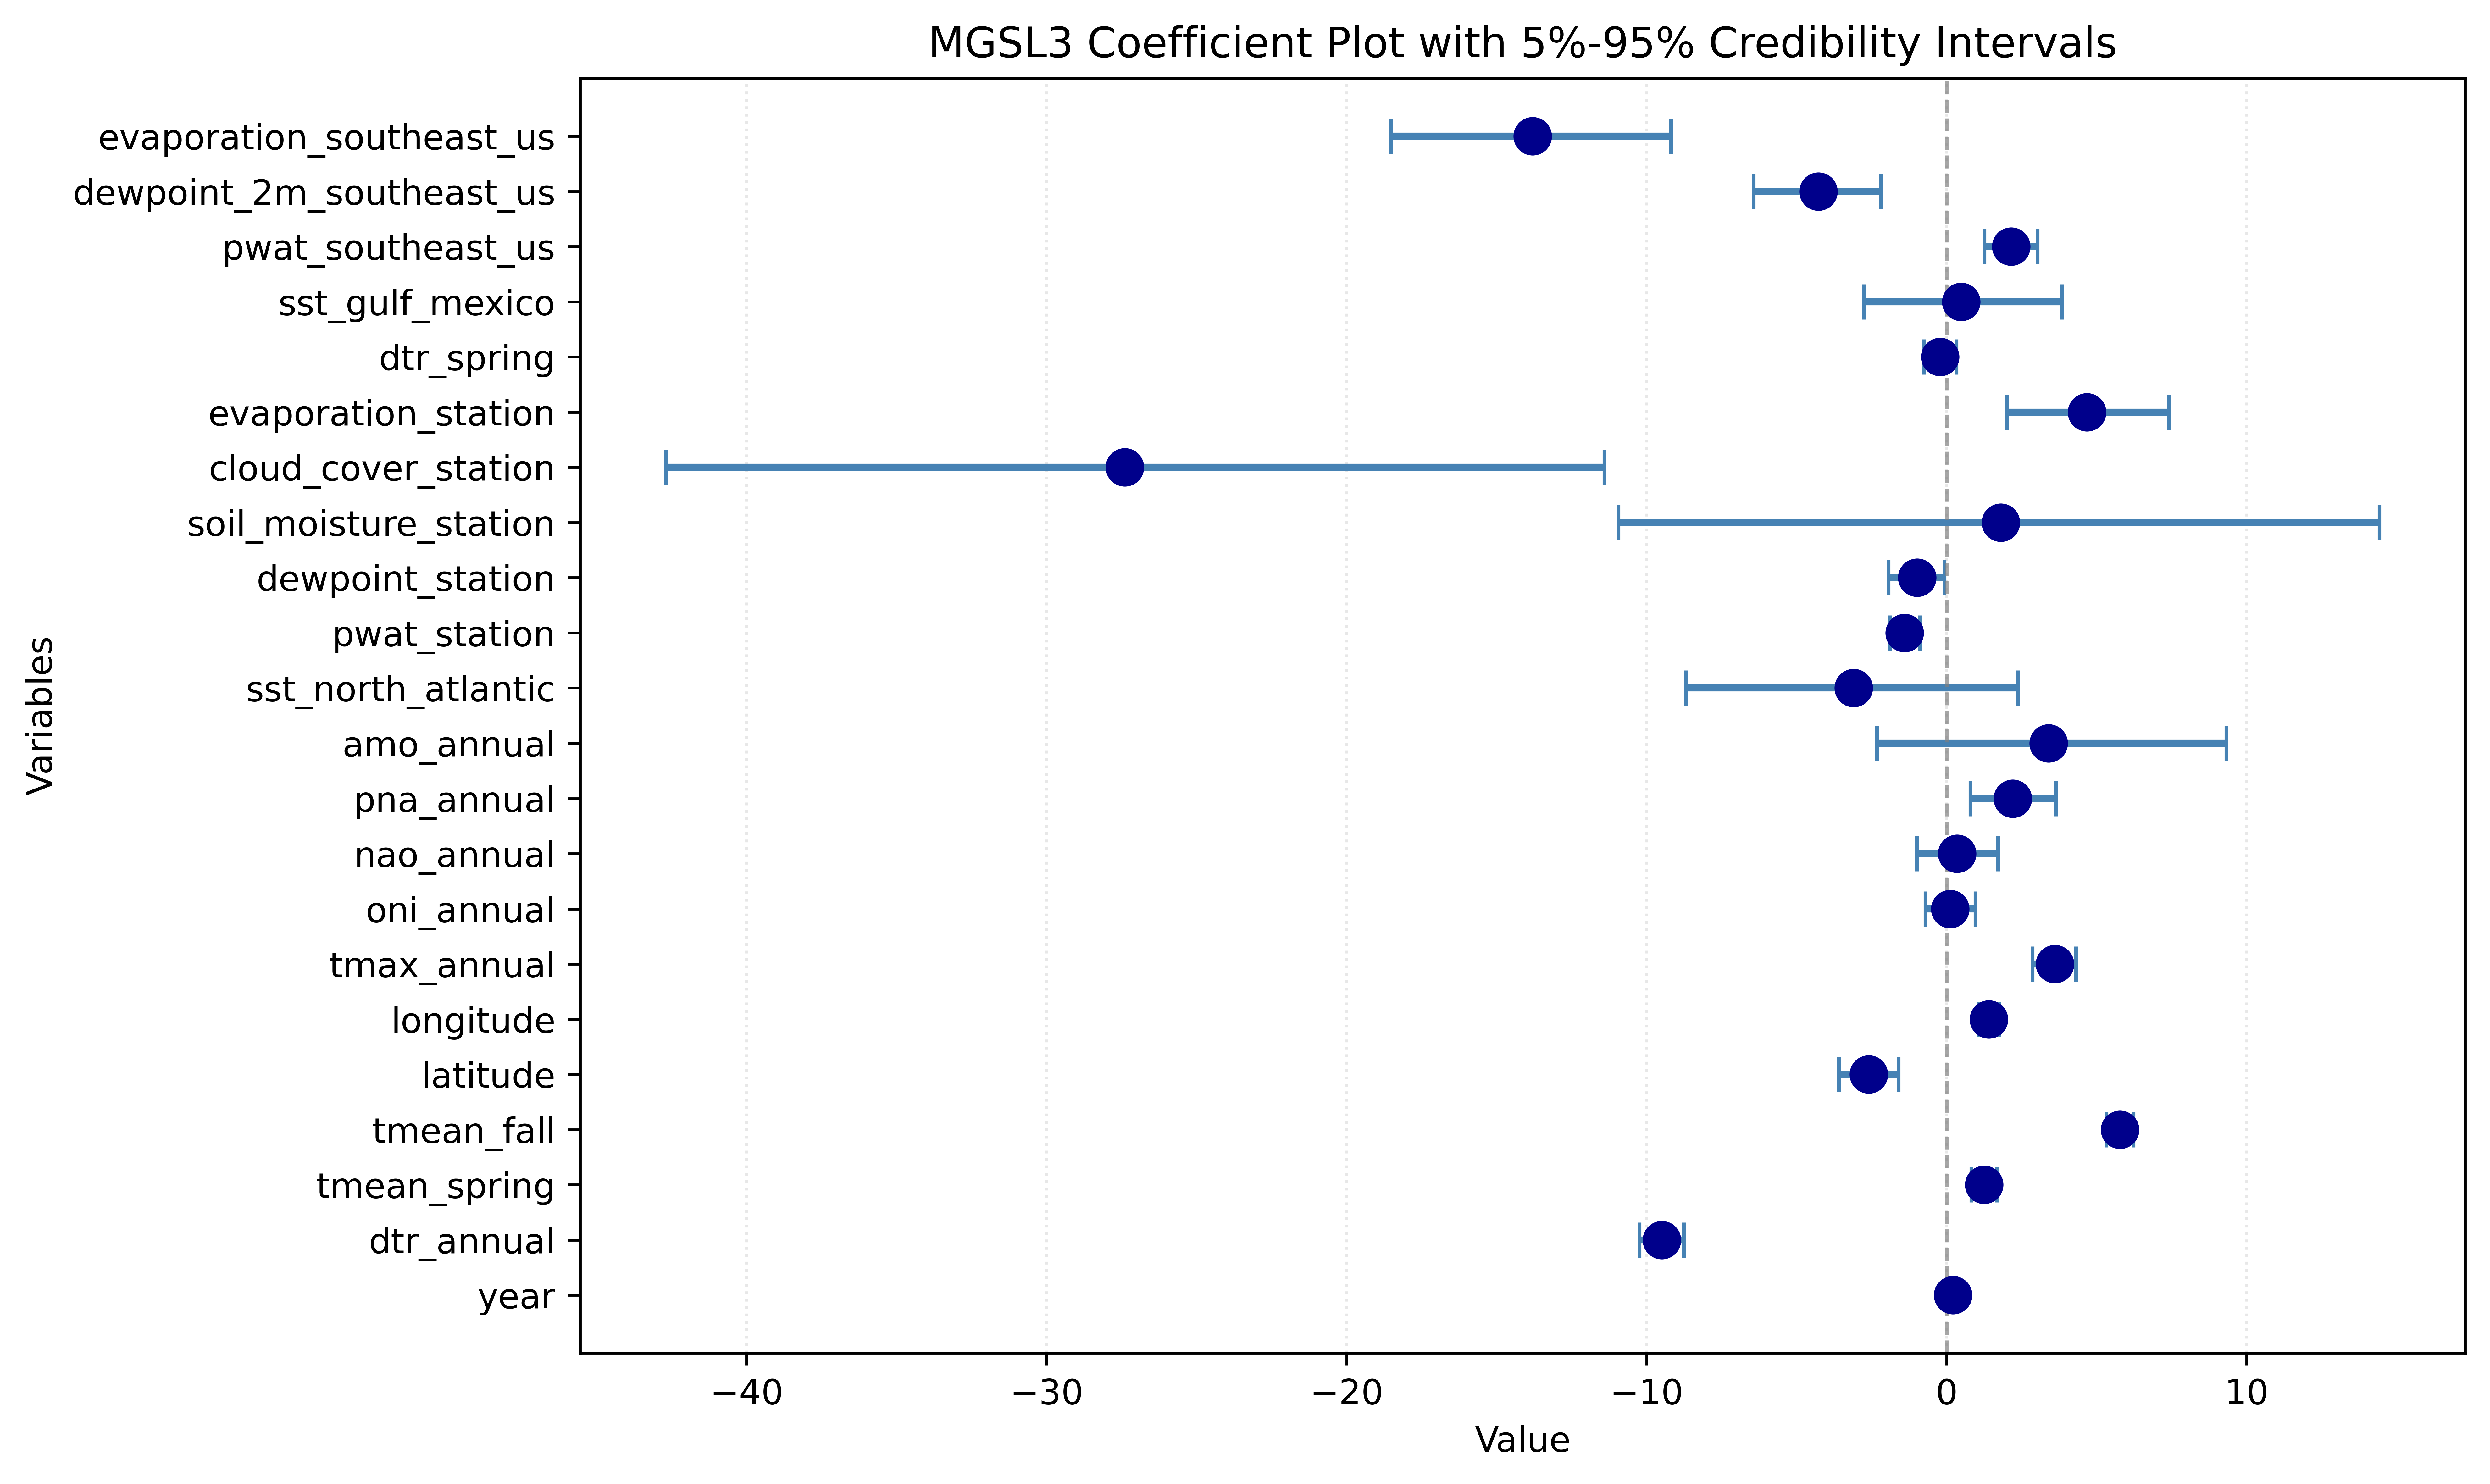

In [101]:
fig, ax = plt.subplots(figsize=(10, 6))

gsl_posteriors_plot = gsl_posteriors_df[['year', 'dtr_annual','tmean_spring','tmean_fall','latitude','longitude','tmax_annual','oni_annual',
                'nao_annual','pna_annual','amo_annual','sst_north_atlantic','pwat_station','dewpoint_station',
                'soil_moisture_station','cloud_cover_station','evaporation_station', 'dtr_spring',
                'sst_gulf_mexico','pwat_southeast_us','dewpoint_2m_southeast_us','evaporation_southeast_us']]

quantile_5 = gsl_posteriors_plot.loc['q05']
quantile_95 = gsl_posteriors_plot.loc['q95']
mean_values = gsl_posteriors_plot.loc['mean']

mean_values_float = mean_values.astype(float)
quantile_5_float = quantile_5.astype(float)
quantile_95_float = quantile_95.astype(float)

variables = mean_values.index.tolist()

lower_error = mean_values_float - quantile_5_float
upper_error = quantile_95_float - mean_values_float

y_positions = np.arange(len(variables))

ax.scatter(mean_values_float, y_positions, color='darkblue', s=100, zorder=3, label='Mean')

ax.errorbar(mean_values_float, y_positions, 
            xerr=[lower_error.values, upper_error.values],  # Convert Series to numpy arrays
            fmt='none', ecolor='steelblue', elinewidth=2, capsize=5, zorder=2)

ax.axvline(x=0, color='gray', linestyle='--', linewidth=1, alpha=0.7)

ax.set_yticks(y_positions)
ax.set_yticklabels(variables)

ax.set_xlabel('Value')
ax.set_ylabel('Variables')
ax.set_title('MGSL3 Coefficient Plot with 5%-95% Credibility Intervals')

ax.grid(axis='x', alpha=0.3, linestyle=':')

plt.tight_layout()
plt.rcParams['figure.dpi'] = 800
plt.rcParams['savefig.dpi'] = 800
plt.show()